In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error,r2_score
import numpy as np
import matplotlib.pyplot as plt
import joblib

In [ ]:
import pandas as pd
gen_df = pd.read_csv("Plant_1_Generation_Data.csv.zip")
weather_df = pd.read_csv("Plant_1_Weather_Sensor_Data.csv")

print(gen_df.shape)
print(weather_df.shape)

(68778, 7)
(3182, 6)


In [ ]:
gen_df["DATE_TIME"] = pd.to_datetime(gen_df["DATE_TIME"], format="%d-%m-%Y %H:%M")
weather_df["DATE_TIME"] = pd.to_datetime(weather_df["DATE_TIME"])

In [ ]:
df = pd.merge(
    gen_df,
    weather_df,
    on=["DATE_TIME", "PLANT_ID"],
    how="inner"
)

In [ ]:
df = df.sort_values("DATE_TIME").reset_index(drop=True)

print(df.head())

   DATE_TIME  PLANT_ID     SOURCE_KEY_x  DC_POWER  AC_POWER  DAILY_YIELD  \
0 2020-05-15   4135001  1BY6WEcLGh8j5v7       0.0       0.0          0.0   
1 2020-05-15   4135001  zVJPv84UY57bAof       0.0       0.0          0.0   
2 2020-05-15   4135001  zBIq5rxdHJRwDNY       0.0       0.0          0.0   
3 2020-05-15   4135001  z9Y9gH1T5YWrNuG       0.0       0.0          0.0   
4 2020-05-15   4135001  wCURE6d3bPkepu2       0.0       0.0          0.0   

   TOTAL_YIELD     SOURCE_KEY_y  AMBIENT_TEMPERATURE  MODULE_TEMPERATURE  \
0    6259559.0  HmiyD2TTLFNqkNe            25.184316           22.857507   
1    7116151.0  HmiyD2TTLFNqkNe            25.184316           22.857507   
2    6339380.0  HmiyD2TTLFNqkNe            25.184316           22.857507   
3    7007866.0  HmiyD2TTLFNqkNe            25.184316           22.857507   
4    6782598.0  HmiyD2TTLFNqkNe            25.184316           22.857507   

   IRRADIATION  
0          0.0  
1          0.0  
2          0.0  
3          0.0  
4

In [ ]:
df["DC_POWER"] = df["DC_POWER"].interpolate(method="linear")
df["AMBIENT_TEMPERATURE"] = df["AMBIENT_TEMPERATURE"].interpolate(method="linear")
df["MODULE_TEMPERATURE"] = df["MODULE_TEMPERATURE"].interpolate(method="linear")
df["IRRADIATION"] = df["IRRADIATION"].ffill()
df = df.dropna().reset_index(drop=True)

print("Missing values after handling:\n")
print(df.isnull().sum())

Missing values after handling:

DATE_TIME              0
PLANT_ID               0
SOURCE_KEY_x           0
DC_POWER               0
AC_POWER               0
DAILY_YIELD            0
TOTAL_YIELD            0
SOURCE_KEY_y           0
AMBIENT_TEMPERATURE    0
MODULE_TEMPERATURE     0
IRRADIATION            0
dtype: int64


In [ ]:
df = df.drop(columns=[
    "SOURCE_KEY_x",
    "SOURCE_KEY_y",
    "DAILY_YIELD",
    "TOTAL_YIELD",
    "AC_POWER"
])

print(df.columns)

print(df.describe())

Index(['DATE_TIME', 'PLANT_ID', 'DC_POWER', 'AMBIENT_TEMPERATURE',
       'MODULE_TEMPERATURE', 'IRRADIATION'],
      dtype='object')
                           DATE_TIME   PLANT_ID      DC_POWER  \
count                          68774    68774.0  68774.000000   
mean   2020-06-01 08:02:38.161514240  4135001.0   3147.177450   
min              2020-05-15 00:00:00  4135001.0      0.000000   
25%              2020-05-24 00:33:45  4135001.0      0.000000   
50%              2020-06-01 14:15:00  4135001.0    428.571429   
75%              2020-06-09 20:00:00  4135001.0   6365.468750   
max              2020-06-17 23:45:00  4135001.0  14471.125000   
std                              NaN        0.0   4036.441826   

       AMBIENT_TEMPERATURE  MODULE_TEMPERATURE   IRRADIATION  
count         68774.000000        68774.000000  68774.000000  
mean             25.558521           31.244997      0.232305  
min              20.398505           18.140415      0.000000  
25%              22.724491  

In [ ]:
df = df.sort_values("DATE_TIME").reset_index(drop=True)
df["hour"] = df["DATE_TIME"].dt.hour
df["month"] = df["DATE_TIME"].dt.month

print(df.head())

   DATE_TIME  PLANT_ID  DC_POWER  AMBIENT_TEMPERATURE  MODULE_TEMPERATURE  \
0 2020-05-15   4135001       0.0            25.184316           22.857507   
1 2020-05-15   4135001       0.0            25.184316           22.857507   
2 2020-05-15   4135001       0.0            25.184316           22.857507   
3 2020-05-15   4135001       0.0            25.184316           22.857507   
4 2020-05-15   4135001       0.0            25.184316           22.857507   

   IRRADIATION  hour  month  
0          0.0     0      5  
1          0.0     0      5  
2          0.0     0      5  
3          0.0     0      5  
4          0.0     0      5  


In [ ]:
gen_agg = gen_df.groupby("DATE_TIME").agg({
    "DC_POWER": "sum"
}).reset_index()

In [ ]:
df = pd.merge(
    gen_agg,
    weather_df[["DATE_TIME", "AMBIENT_TEMPERATURE", "MODULE_TEMPERATURE", "IRRADIATION"]],
    on="DATE_TIME",
    how="inner"
)

In [ ]:
df = df.sort_values("DATE_TIME").reset_index(drop=True)

print(df.head())
print(df.shape)

            DATE_TIME  DC_POWER  AMBIENT_TEMPERATURE  MODULE_TEMPERATURE  \
0 2020-05-15 00:00:00       0.0            25.184316           22.857507   
1 2020-05-15 00:15:00       0.0            25.084589           22.761668   
2 2020-05-15 00:30:00       0.0            24.935753           22.592306   
3 2020-05-15 00:45:00       0.0            24.846130           22.360852   
4 2020-05-15 01:00:00       0.0            24.621525           22.165423   

   IRRADIATION  
0          0.0  
1          0.0  
2          0.0  
3          0.0  
4          0.0  
(3157, 5)


In [ ]:
df["hour"] = df["DATE_TIME"].dt.hour
df["dayofyear"] = df["DATE_TIME"].dt.dayofyear
df["month"] = df["DATE_TIME"].dt.month

print(df.head())

            DATE_TIME  DC_POWER  AMBIENT_TEMPERATURE  MODULE_TEMPERATURE  \
0 2020-05-15 00:00:00       0.0            25.184316           22.857507   
1 2020-05-15 00:15:00       0.0            25.084589           22.761668   
2 2020-05-15 00:30:00       0.0            24.935753           22.592306   
3 2020-05-15 00:45:00       0.0            24.846130           22.360852   
4 2020-05-15 01:00:00       0.0            24.621525           22.165423   

   IRRADIATION  hour  dayofyear  month  
0          0.0     0        136      5  
1          0.0     0        136      5  
2          0.0     0        136      5  
3          0.0     0        136      5  
4          0.0     1        136      5  


In [ ]:
df["lag_1"] = df["DC_POWER"].shift(1)
df["lag_4"] = df["DC_POWER"].shift(4)
df["rolling_mean_4"] = df["DC_POWER"].rolling(window=4).mean()
df = df.dropna().reset_index(drop=True)

print(df.head())
print(df.shape)

            DATE_TIME  DC_POWER  AMBIENT_TEMPERATURE  MODULE_TEMPERATURE  \
0 2020-05-15 01:00:00       0.0            24.621525           22.165423   
1 2020-05-15 01:15:00       0.0            24.536092           21.968571   
2 2020-05-15 01:30:00       0.0            24.638674           22.352926   
3 2020-05-15 01:45:00       0.0            24.873022           23.160919   
4 2020-05-15 02:00:00       0.0            24.936930           23.026113   

   IRRADIATION  hour  dayofyear  month  lag_1  lag_4  rolling_mean_4  
0          0.0     1        136      5    0.0    0.0             0.0  
1          0.0     1        136      5    0.0    0.0             0.0  
2          0.0     1        136      5    0.0    0.0             0.0  
3          0.0     1        136      5    0.0    0.0             0.0  
4          0.0     2        136      5    0.0    0.0             0.0  
(3153, 11)


In [ ]:
df["target"] = df["DC_POWER"].shift(-1)
df = df.dropna().reset_index(drop=True)

print(df[["DC_POWER", "target"]].head())

   DC_POWER  target
0       0.0     0.0
1       0.0     0.0
2       0.0     0.0
3       0.0     0.0
4       0.0     0.0


In [ ]:
y = df["target"]

X = df.drop(columns=[
    "DATE_TIME",
    "DC_POWER",
    "target"
])

In [ ]:
split_index = int(len(df) * 0.8)

X_train = X.iloc[:split_index]
X_test  = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test  = y.iloc[split_index:]

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (2521, 9)
Test size: (631, 9)


In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

model = RandomForestRegressor(
    n_estimators=200,
    max_depth=12,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

preds = model.predict(X_test)

mae = mean_absolute_error(y_test, preds)
rmse = np.sqrt(mean_squared_error(y_test, preds))
r2 = r2_score(y_test, preds)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

MAE: 10573.810102716383
RMSE: 21207.710057670523
R2: 0.9323337701435448


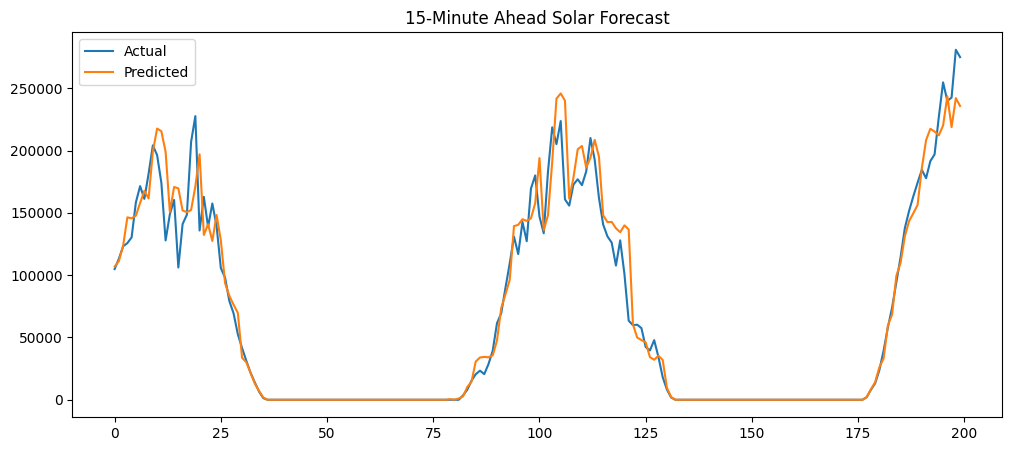

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(y_test.values[:200], label="Actual")
plt.plot(preds[:200], label="Predicted")
plt.legend()
plt.title("15-Minute Ahead Solar Forecast")
plt.show()

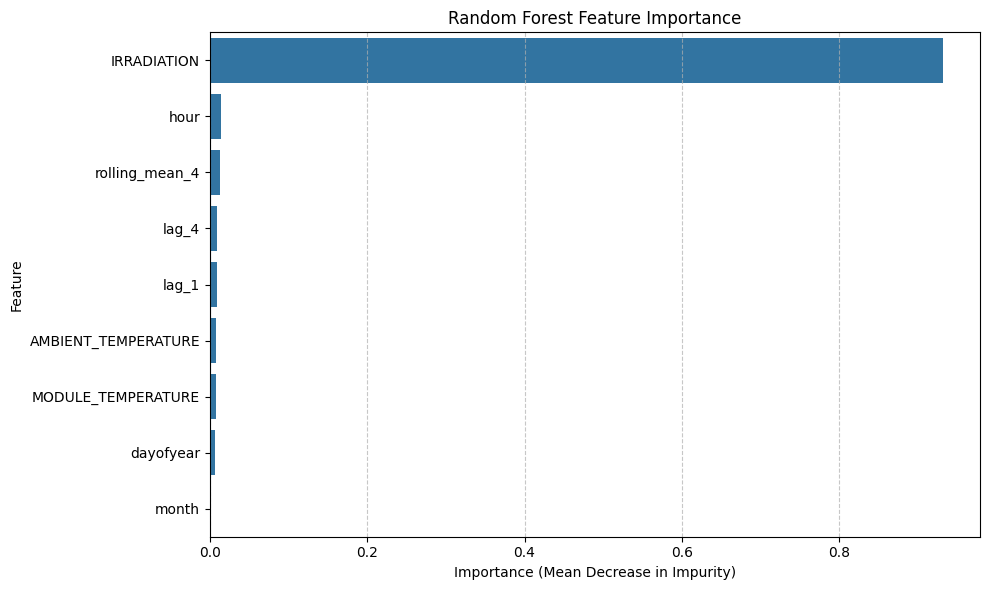

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
feature_importances = model.feature_importances_
feature_names = X_train.columns
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importances
}).sort_values(by='Importance', ascending=False)
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df)
plt.title('Random Forest Feature Importance')
plt.xlabel('Importance (Mean Decrease in Impurity)')
plt.ylabel('Feature')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
import joblib

joblib.dump(model, "solar_forecast_model.pkl")

['solar_forecast_model.pkl']